In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
file_path = 'heart.csv'
df = pd.read_csv(file_path)

print("Display the first 5 rows of the dataset:")
print(df.head())

Display the first 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
print(f"\nNumber of rows and columns: {df.shape}")

print("\nGeneral dataset information (info):")
df.info()

print("\nNumber of missing values ​​in each column:")
print(df.isnull().sum())

print("\nStatistical summary of numeric columns:")
print(df.describe())


Number of rows and columns: (303, 14)

General dataset information (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Number of missing values ​​in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
t

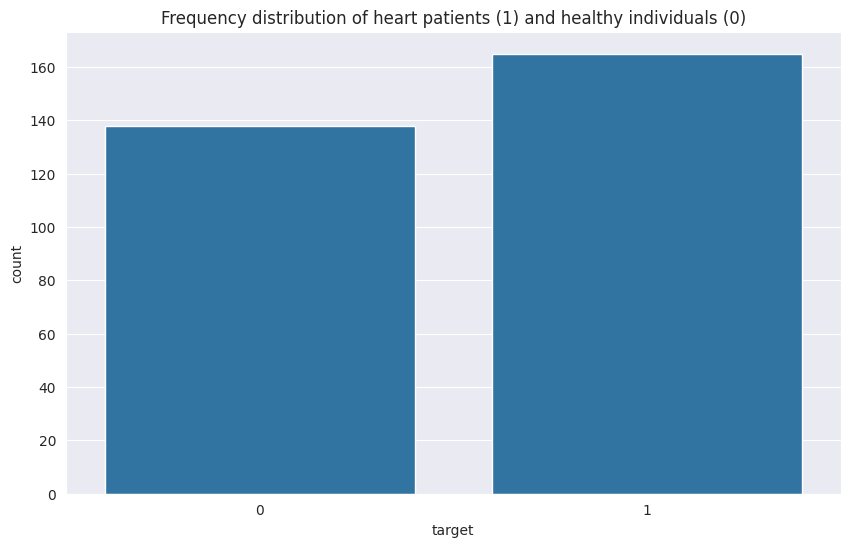

Number of patients and healthy people:
target
1    165
0    138
Name: count, dtype: int64


In [ ]:
plt.title('Frequency distribution of heart patients (1) and healthy individuals (0)')
sns.countplot(x='target', data=df)
plt.show()

print("Number of patients and healthy people:")
print(df['target'].value_counts())

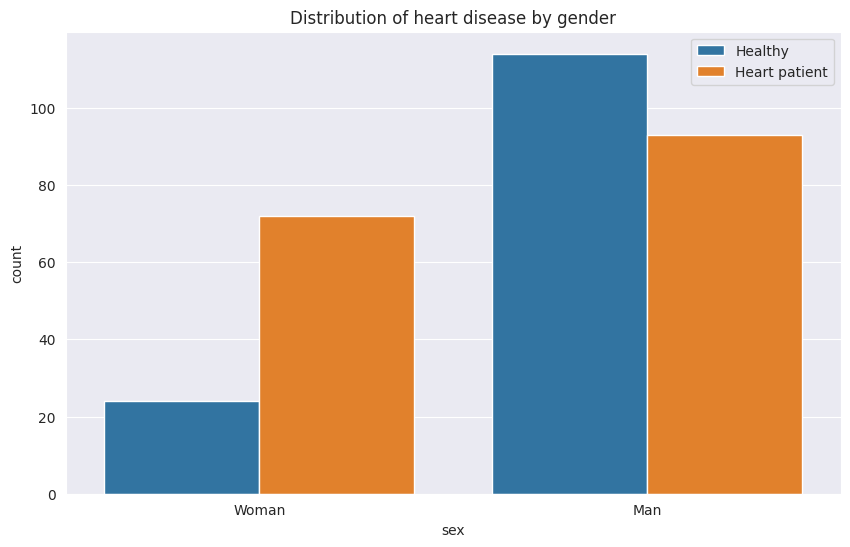

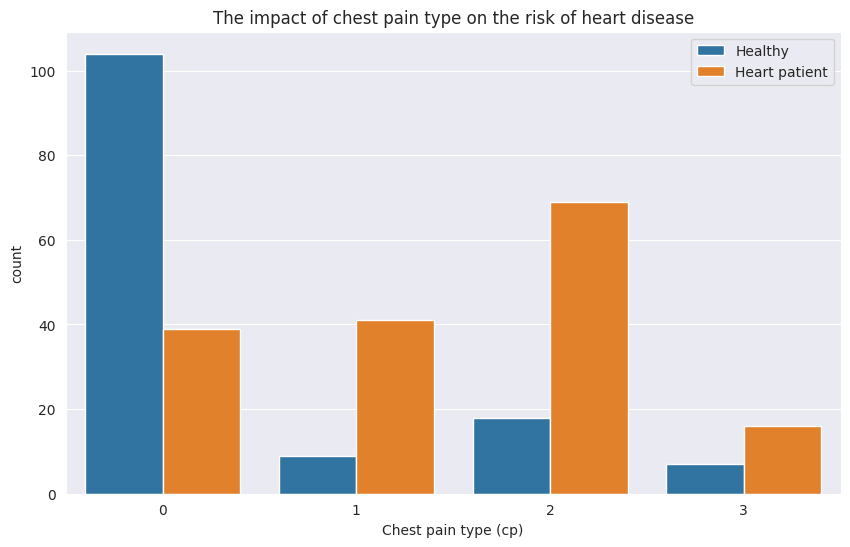

In [ ]:
plt.title('Distribution of heart disease by gender')
sns.countplot(x='sex', hue='target', data=df)
plt.xticks([0, 1], ['Woman', 'Man'])
plt.legend(['Healthy', 'Heart patient'])
plt.show()

plt.title('The impact of chest pain type on the risk of heart disease')
sns.countplot(x='cp', hue='target', data=df)
plt.xlabel('Chest pain type (cp)')
plt.legend(['Healthy', 'Heart patient'])
plt.show()

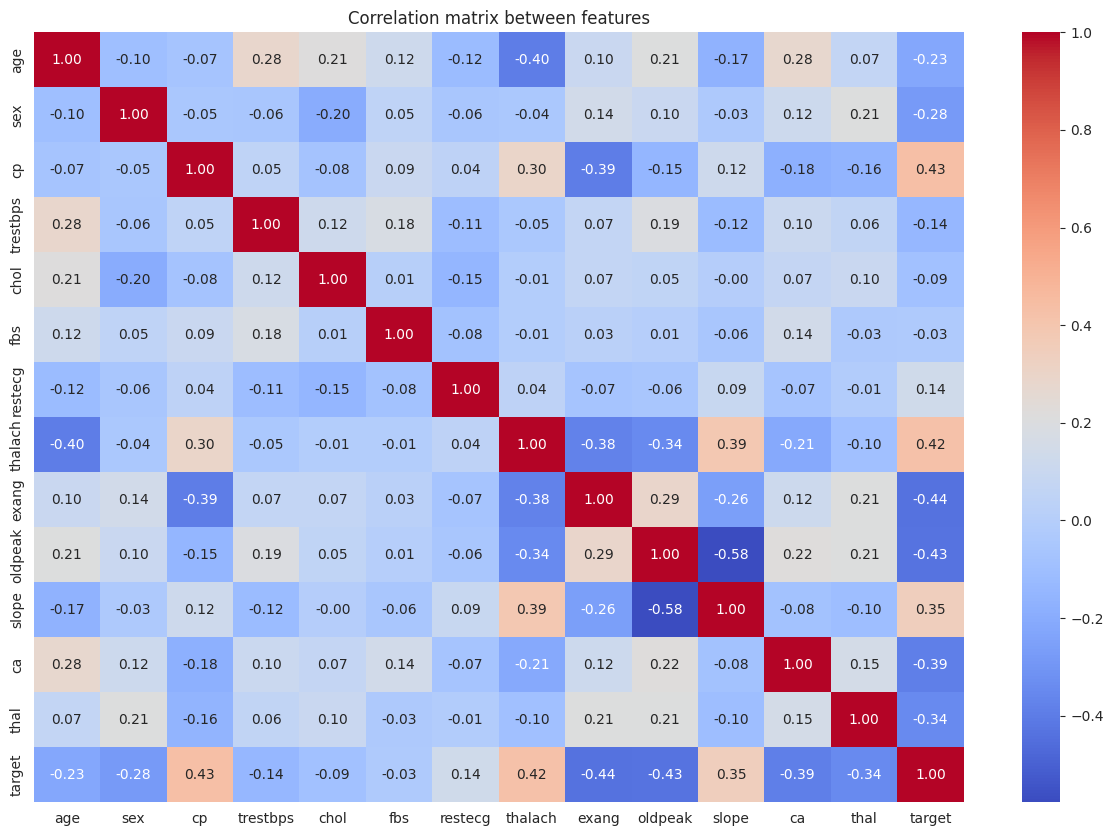

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 10))
plt.title('Correlation matrix between features')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")


if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows have been removed.")
    print(f"New shape of the DataFrame: {df.shape}")

Number of duplicate rows: 1
Duplicate rows have been removed.
New shape of the DataFrame: (302, 14)


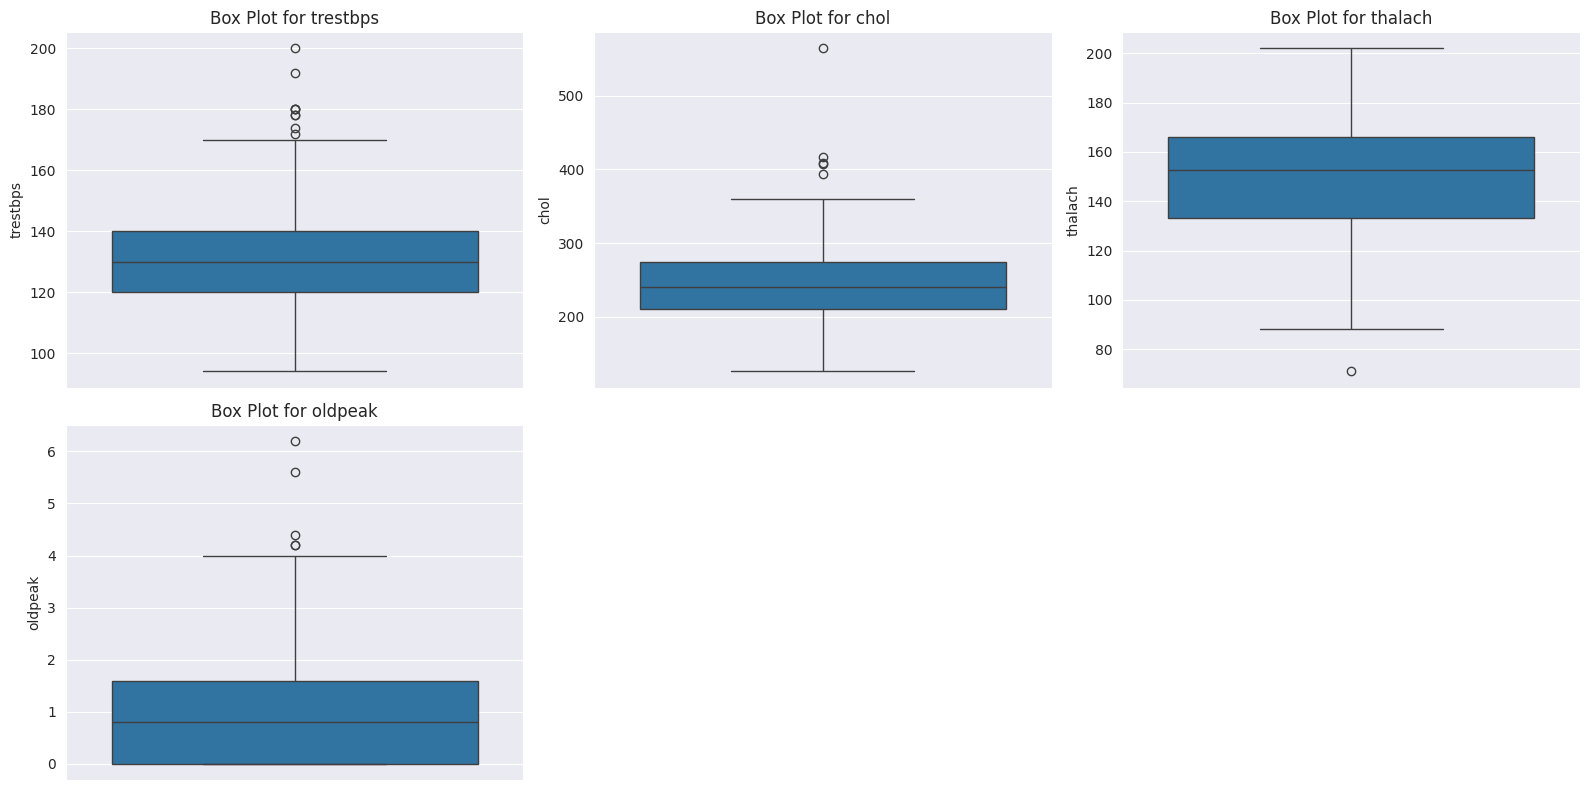

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
sns.boxplot(y=df['trestbps'])
plt.title('Box Plot for trestbps')

plt.subplot(2, 3, 2)
sns.boxplot(y=df['chol'])
plt.title('Box Plot for chol')

plt.subplot(2, 3, 3)
sns.boxplot(y=df['thalach'])
plt.title('Box Plot for thalach')

plt.subplot(2, 3, 4)
sns.boxplot(y=df['oldpeak'])
plt.title('Box Plot for oldpeak')

plt.tight_layout()
plt.show()

Capping outliers...
Outliers have been capped.


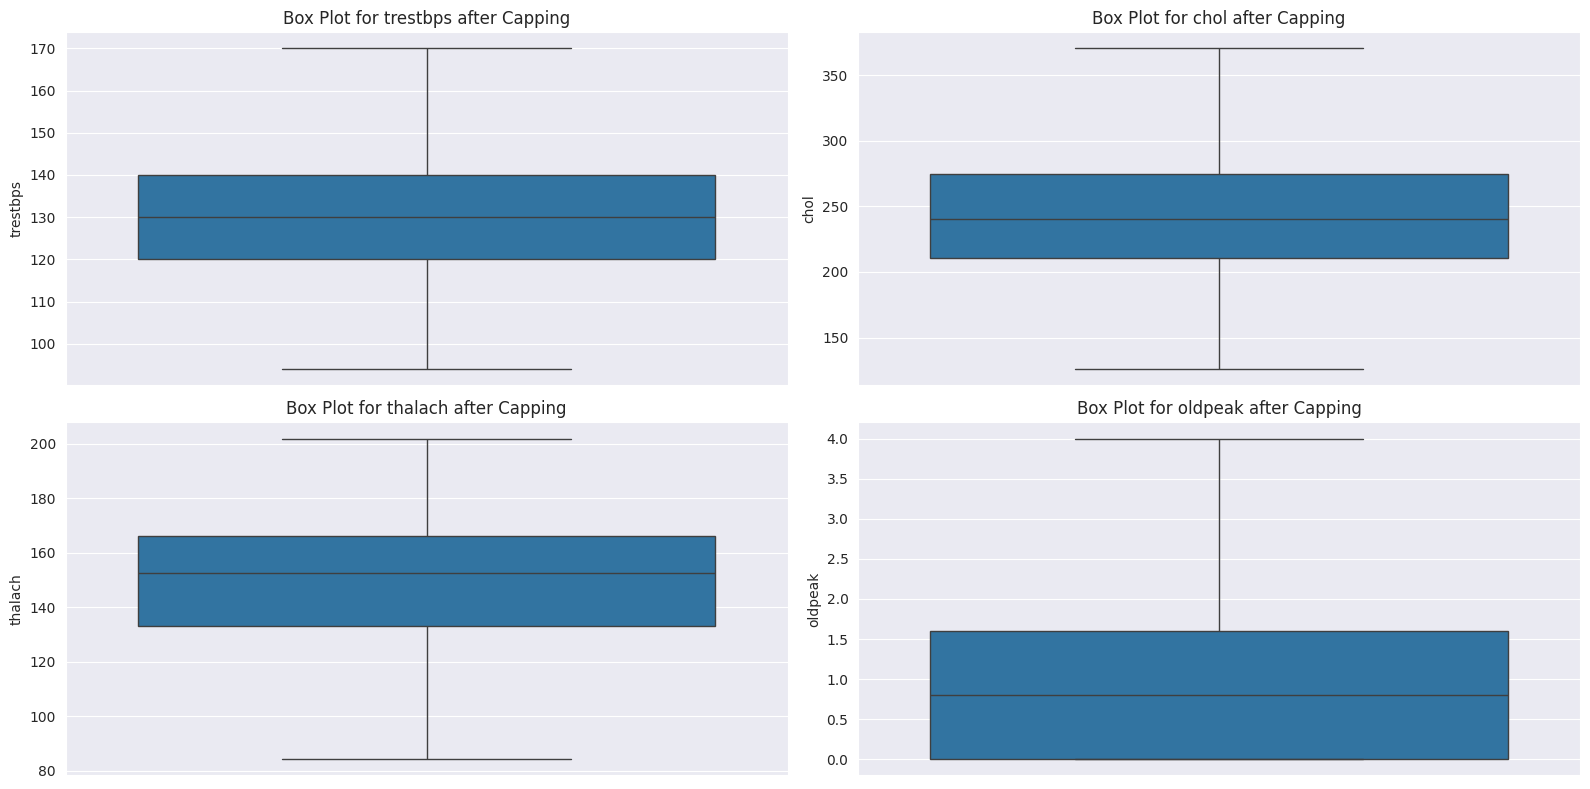

In [ ]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] > upper_bound, upper_bound,
                          np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

columns_with_outliers = ['trestbps', 'chol', 'thalach', 'oldpeak']

print("Capping outliers...")
for col in columns_with_outliers:
    df = cap_outliers(df, col)

print("Outliers have been capped.")
plt.figure(figsize=(16, 8))
for i, col in enumerate(columns_with_outliers, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot for {col} after Capping')

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (241, 13)
Shape of X_test: (61, 13)
Shape of y_train: (241,)
Shape of y_test: (61,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nFirst 5 rows of the scaled training data:")
print(X_train_scaled.head())


First 5 rows of the scaled training data:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.289062 -1.473449 -0.935691 -0.179898  1.264028 -0.405279 -1.041992   
1  1.267182  0.678680  0.062103  1.728457  0.045152 -0.405279  0.846129   
2  0.071702 -1.473449 -0.935691 -0.179898 -0.831583 -0.405279  2.734250   
3  0.289062  0.678680 -0.935691 -1.253348  1.948310 -0.405279  0.846129   
4  0.397742  0.678680  1.059898  0.535735 -0.703281  2.467435 -1.041992   

    thalach     exang   oldpeak     slope        ca      thal  
0  0.405122 -0.718139 -0.920726  0.964611  0.264036 -0.575142  
1 -1.364273  1.392489 -0.920726 -0.638639  2.221962 -2.245133  
2 -0.910582  1.392489  0.829925 -0.638639  0.264036  1.094849  
3 -0.320784  1.392489  1.705250 -0.638639  0.264036  1.094849  
4  0.677336 -0.718139 -0.920726  0.964611 -0.714928 -0.575142  


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


--- Training Naive Bayes Model ---
Model trained successfully.

--- Naive Bayes Model Evaluation ---
Accuracy: 0.8197

Confusion Matrix:
[[20  8]
 [ 3 30]]


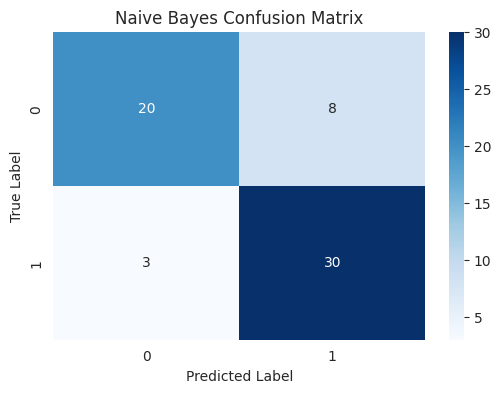

In [ ]:
nb_model = GaussianNB()

print("--- Training Naive Bayes Model ---")
nb_model.fit(X_train_scaled, y_train)
print("Model trained successfully.")


y_pred_nb = nb_model.predict(X_test_scaled)


print("\n--- Naive Bayes Model Evaluation ---")

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {accuracy_nb:.4f}")


cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix:")
print(cm_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Training Decision Tree Model ---
Model trained successfully.

--- Decision Tree Model Evaluation ---
Accuracy: 0.8197

Confusion Matrix:
[[17 11]
 [ 0 33]]


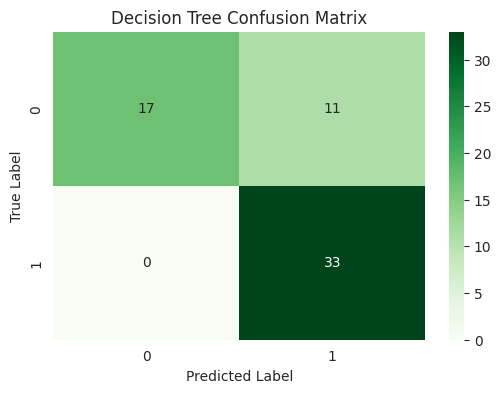

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)


print("\n--- Training Decision Tree Model ---")
dt_model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

y_pred_dt = dt_model.predict(X_test_scaled)


print("\n--- Decision Tree Model Evaluation ---")

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")


cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(cm_dt)


plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Training SVM Model ---
Model trained successfully.

--- SVM Model Evaluation ---
Accuracy: 0.8525

Confusion Matrix:
[[20  8]
 [ 1 32]]


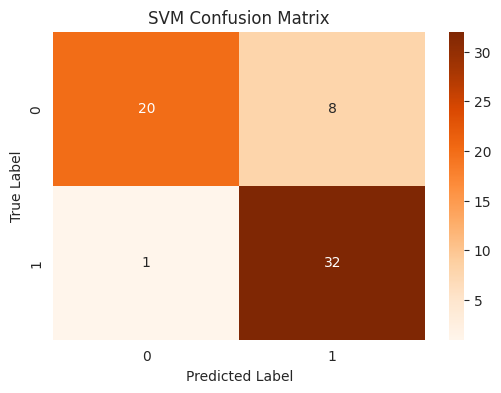

In [ ]:
svm_model = SVC(kernel='rbf', random_state=42)

print("\n--- Training SVM Model ---")
svm_model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

y_pred_svm = svm_model.predict(X_test_scaled)

print("\n--- SVM Model Evaluation ---")

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")


cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
print(cm_svm)


plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print("\n--- Final Model Comparison ---")
models_accuracy = {
    'Naive Bayes': accuracy_nb,
    'Decision Tree': accuracy_dt,
    'SVM': accuracy_svm
}


for model, acc in models_accuracy.items():
    print(f"Accuracy of {model}: {acc:.4f}")

best_model_name = max(models_accuracy, key=models_accuracy.get)
print(f"\nBest performing model: {best_model_name} with an accuracy of {models_accuracy[best_model_name]:.4f}")


--- Final Model Comparison ---
Accuracy of Naive Bayes: 0.8197
Accuracy of Decision Tree: 0.8197
Accuracy of SVM: 0.8525

Best performing model: SVM with an accuracy of 0.8525


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

--- Training KNN Model ---
Model trained successfully.

--- KNN Model Evaluation ---
Accuracy: 0.8197

Confusion Matrix:
[[20  8]
 [ 3 30]]


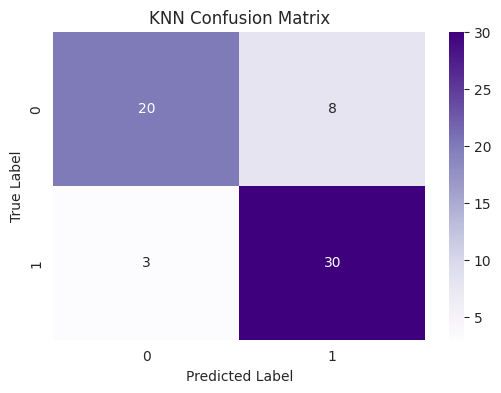

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)

print("--- Training KNN Model ---")
knn_model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

y_pred_knn = knn_model.predict(X_test_scaled)


print("\n--- KNN Model Evaluation ---")

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:")
print(cm_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Training Logistic Regression Model ---
Model trained successfully.

--- Logistic Regression Model Evaluation ---
Accuracy: 0.8033

Confusion Matrix:
[[19  9]
 [ 3 30]]


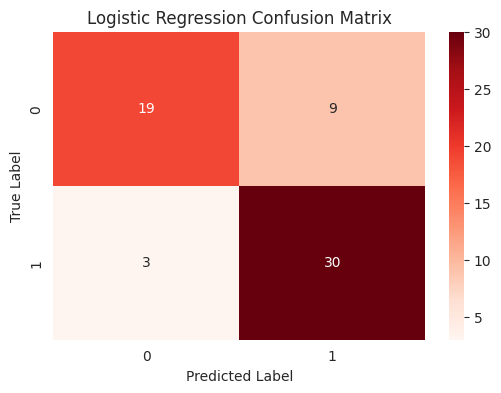

In [ ]:
lr_model = LogisticRegression(random_state=42)


print("\n--- Training Logistic Regression Model ---")
lr_model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

y_pred_lr = lr_model.predict(X_test_scaled)

print("\n--- Logistic Regression Model Evaluation ---")

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Final Model Comparison ---
Accuracy of SVM: 0.8525
Accuracy of Naive Bayes: 0.8197
Accuracy of Decision Tree: 0.8197
Accuracy of KNN: 0.8197
Accuracy of Logistic Regression: 0.8033


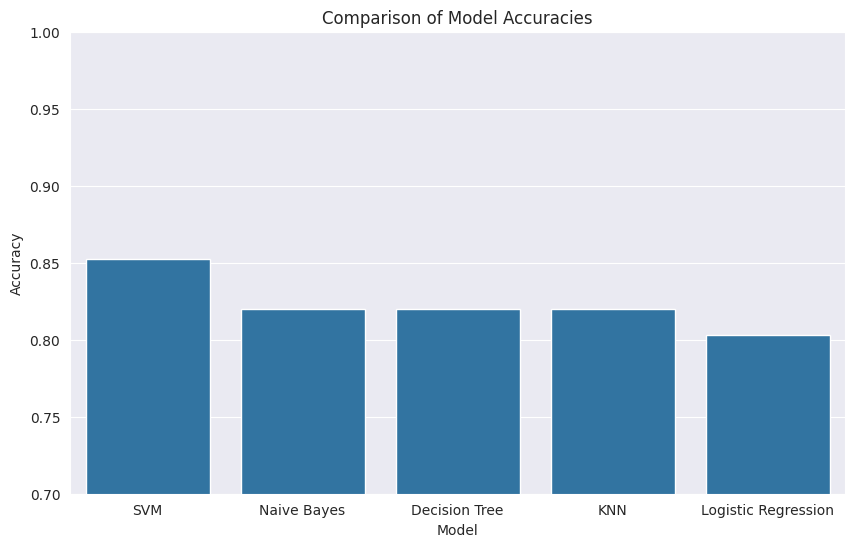

In [ ]:
models_accuracy['KNN'] = accuracy_knn
models_accuracy['Logistic Regression'] = accuracy_lr

sorted_accuracies = sorted(models_accuracy.items(), key=lambda item: item[1], reverse=True)

print("\n--- Final Model Comparison ---")
for model, acc in sorted_accuracies:
    print(f"Accuracy of {model}: {acc:.4f}")

plt.figure(figsize=(10, 6))
model_names = [item[0] for item in sorted_accuracies]
model_accs = [item[1] for item in sorted_accuracies]
sns.barplot(x=model_names, y=model_accs)
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()